# Receipt OCR Detection — 발표용 EDA

- **목적**: 데이터 규모, 해상도·어노테이션 분포, 샘플 시각화
- **데이터**: `dataset_base_path` 기준 train/val JSON + 이미지
- **산출물**: 통계 표, 히스토그램, GT 오버레이 샘플 (발표 슬라이드용)

In [7]:
# configs/preset/datasets/db.yaml 과 동일한 경로
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from IPython.display import display, Image as IDisplayImage

DATASET_BASE = Path("/root/imeanseo_ocr/data/datasets")
IMAGES_TRAIN = DATASET_BASE / "images" / "train"
IMAGES_VAL   = DATASET_BASE / "images" / "val"
JSON_TRAIN   = DATASET_BASE / "jsons" / "train.json"
JSON_VAL     = DATASET_BASE / "jsons" / "val.json"

# 발표용 그림 저장 (True 로 바꾸면 figures/ 폴더에 저장)
SAVE_FIGURES = False
FIG_DIR = Path("figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# 렌더러 오류 시에도 그림이 보이도록: 파일로 저장 후 Image로 표시
def show_fig(name="fig"):
    path = FIG_DIR / f"{name}.png"
    plt.savefig(path, dpi=120, bbox_inches="tight")
    display(IDisplayImage(filename=str(path)))
    plt.show()

def load_annotations(json_path):
    if not Path(json_path).exists():
        return None
    with open(json_path, "r") as f:
        return json.load(f)

In [8]:
# 1) 데이터셋 개요 통계
train_ann = load_annotations(JSON_TRAIN)
val_ann   = load_annotations(JSON_VAL)

def get_stats(ann, split_name):
    if ann is None or "images" not in ann:
        return {"split": split_name, "n_images": 0, "total_words": 0, "mean_words": 0.0}
    n_images = 0
    total_words = 0
    for fn, content in ann["images"].items():
        words = content.get("words", {})
        n = sum(1 for w in words.values() if w.get("points"))
        n_images += 1
        total_words += n
    mean_words = total_words / n_images if n_images else 0.0
    return {"split": split_name, "n_images": n_images, "total_words": total_words, "mean_words": mean_words}

train_stats = get_stats(train_ann, "train")
val_stats   = get_stats(val_ann, "val")

print("| 구분 | 이미지 수 | 총 단어(폴리곤) 수 | 이미지당 평균 단어 수 |")
print("|------|-----------|---------------------|------------------------|")
for s in [train_stats, val_stats]:
    print(f"| {s['split']} | {s['n_images']} | {s['total_words']} | {s['mean_words']:.1f} |")

| 구분 | 이미지 수 | 총 단어(폴리곤) 수 | 이미지당 평균 단어 수 |
|------|-----------|---------------------|------------------------|
| train | 3272 | 382462 | 116.9 |
| val | 404 | 46714 | 115.6 |


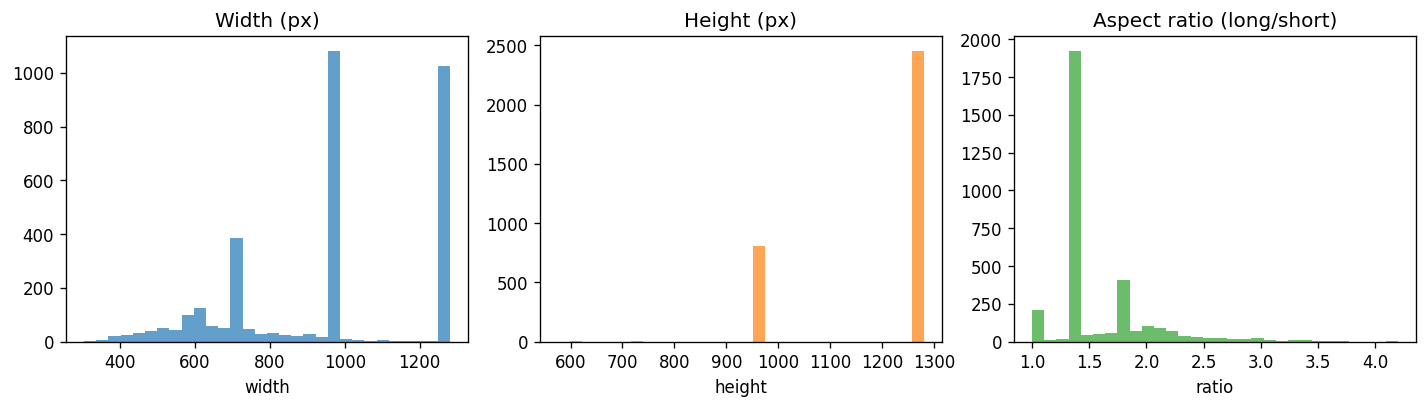

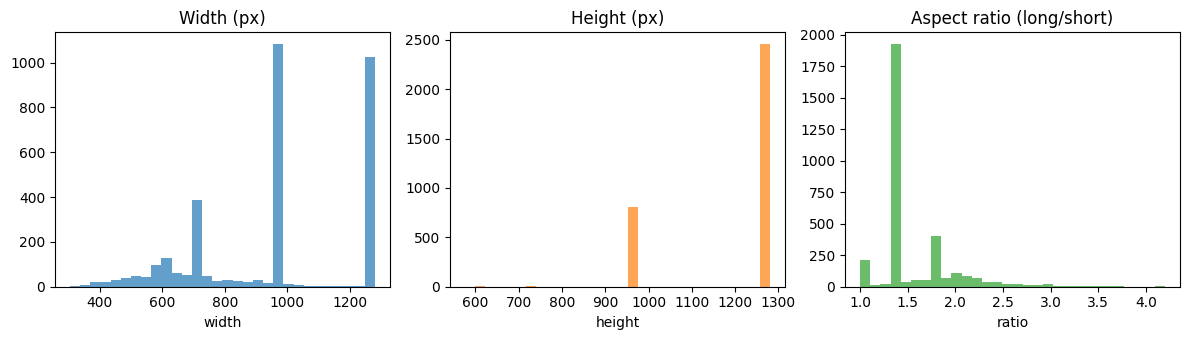

In [9]:
# 2) 이미지 해상도·Aspect ratio 분포 (train만, 이미지 존재하는 것만)
def collect_image_stats(ann, image_dir):
    if ann is None or "images" not in ann:
        return [], [], []
    widths, heights, aspect_ratios = [], [], []
    for fn in ann["images"].keys():
        path = Path(image_dir) / fn
        if not path.exists():
            continue
        try:
            img = Image.open(path)
            w, h = img.size
            widths.append(w)
            heights.append(h)
            aspect_ratios.append(max(w,h) / max(min(w,h), 1))
        except Exception:
            pass
    return widths, heights, aspect_ratios

w_train, h_train, ar_train = collect_image_stats(train_ann, IMAGES_TRAIN)
w_val, h_val, ar_val = collect_image_stats(val_ann, IMAGES_VAL)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
axes[0].hist(w_train, bins=30, alpha=0.7, label="train", color="C0"); axes[0].set_title("Width (px)"); axes[0].set_xlabel("width")
axes[1].hist(h_train, bins=30, alpha=0.7, label="train", color="C1"); axes[1].set_title("Height (px)"); axes[1].set_xlabel("height")
axes[2].hist(ar_train, bins=30, alpha=0.7, label="train", color="C2"); axes[2].set_title("Aspect ratio (long/short)"); axes[2].set_xlabel("ratio")
plt.tight_layout()
show_fig("resolution_distribution")

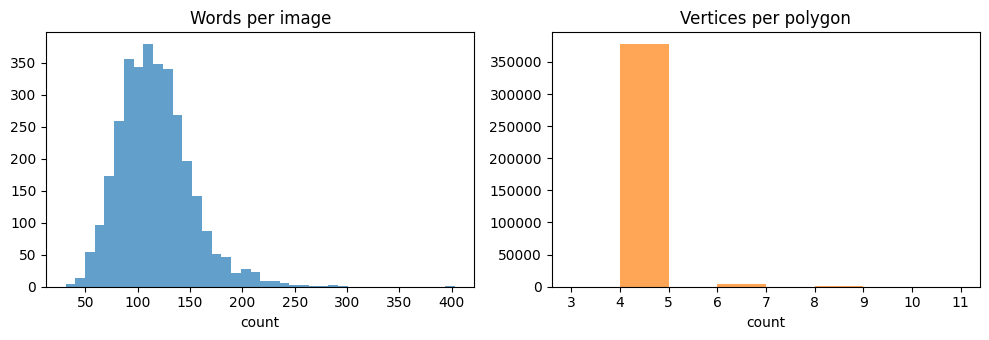

In [5]:
# 3) 이미지당 단어 수 분포 & 폴리곤 꼭짓점 수
def collect_word_stats(ann):
    words_per_image = []
    points_per_poly = []
    if ann is None or "images" not in ann:
        return words_per_image, points_per_poly
    for fn, content in ann["images"].items():
        words = content.get("words", {})
        n = 0
        for w in words.values():
            pts = w.get("points", [])
            if pts:
                n += 1
                points_per_poly.append(len(pts))
        words_per_image.append(n)
    return words_per_image, points_per_poly

train_wpi, train_ppp = collect_word_stats(train_ann)
val_wpi, val_ppp = collect_word_stats(val_ann)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(train_wpi, bins=40, alpha=0.7, label="train", color="C0"); axes[0].set_title("Words per image"); axes[0].set_xlabel("count")
axes[1].hist(train_ppp, bins=range(3, 12), alpha=0.7, color="C1"); axes[1].set_title("Vertices per polygon"); axes[1].set_xlabel("count")
plt.tight_layout()
show_fig("annotation_distribution")

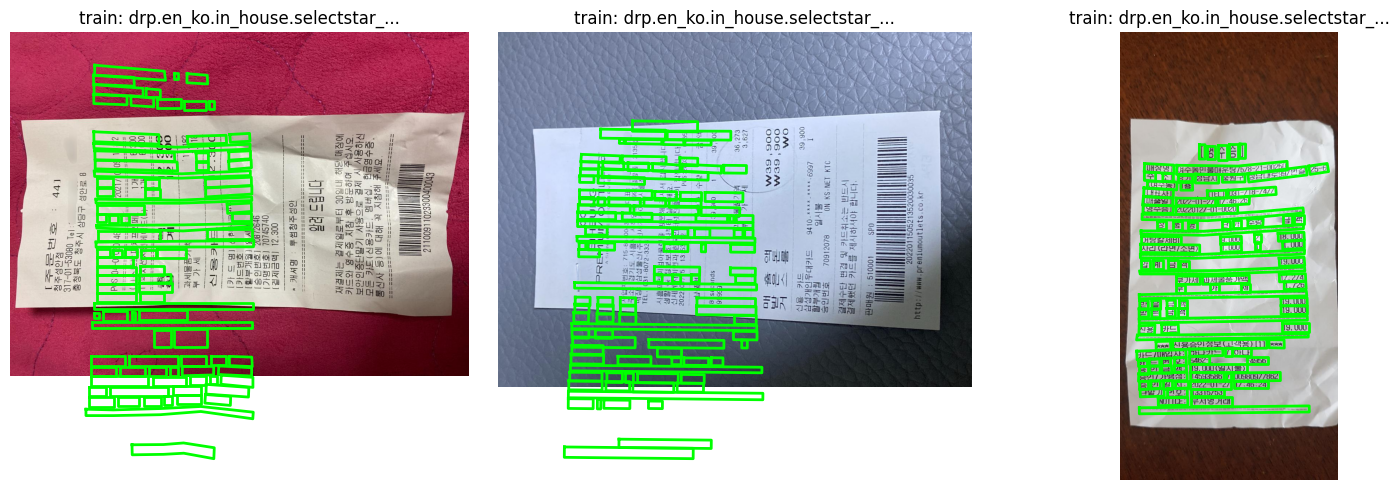

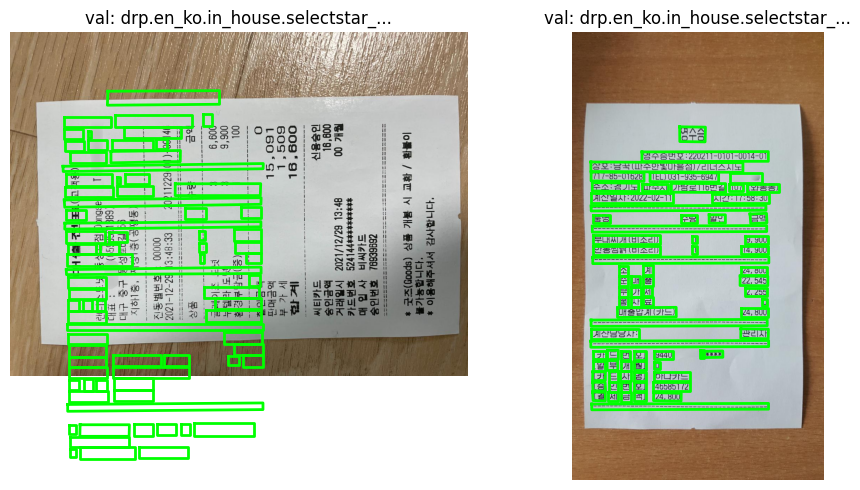

In [6]:
# 4) 샘플 시각화: 원본 이미지 + GT 폴리곤 오버레이
def draw_polygons(ax, polygons, color="lime", linewidth=2):
    for poly in polygons:
        if poly is None or len(poly) == 0:
            continue
        pts = np.array(poly).reshape(-1, 2)
        if len(pts) < 2:
            continue
        pts = np.vstack([pts, pts[0:1]])
        ax.plot(pts[:, 0], pts[:, 1], color=color, linewidth=linewidth)

def show_samples(ann, image_dir, split_name, n=3, indices=None):
    if ann is None or "images" not in ann:
        print(f"{split_name}: no annotations")
        return
    filenames = [f for f in ann["images"].keys() if (Path(image_dir) / f).exists()]
    if not filenames:
        print(f"{split_name}: no images found under {image_dir}")
        return
    if indices is None:
        indices = np.linspace(0, len(filenames)-1, min(n, len(filenames)), dtype=int)
    fig, axes = plt.subplots(1, len(indices), figsize=(5*len(indices), 5))
    if len(indices) == 1:
        axes = [axes]
    for ax, i in zip(axes, indices):
        fn = filenames[i]
        img = np.array(Image.open(Path(image_dir) / fn).convert("RGB"))
        ax.imshow(img)
        words = ann["images"][fn].get("words", {})
        polys = [np.array(w["points"]) for w in words.values() if w.get("points")]
        draw_polygons(ax, polys)
        ax.set_title(f"{split_name}: {fn[:30]}...")
        ax.axis("off")
    plt.tight_layout()
    show_fig(f"sample_gt_{split_name}")

show_samples(train_ann, IMAGES_TRAIN, "train", n=3)
show_samples(val_ann, IMAGES_VAL, "val", n=2)

---
- **라벨 형식**: `images` → filename → `words` → idx → `points` ([[x,y], ...] polygon)
- **태스크**: Word-level 텍스트 영역 검출(Detection) → CLEval (Precision / Recall / Hmean)
- 발표 슬라이드에 쓸 때: 위 표 + 해상도/단어수 히스토그램 + GT 오버레이 샘플 2~3장 사용 권장